# Task 2: Statistical Analysis 

Goal:

1. Primary: Logistic regression (AF → in-hospital mortality), Models 1–4
2. Secondary: Linear regression on log(LOS) for ICU LOS and Hospital LOS
3. Subgroup: HFrEF vs HFpEF
4. Sensitivity: Alternate AF definition
5. Model diagnostics: VIF, AUC, Hosmer-Lemeshow

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)

## Load & Prepare Data

In [2]:
df = pd.read_csv('data/data.csv')

df['admittime'] = pd.to_datetime(df['admittime'], format='mixed')
df['dischtime'] = pd.to_datetime(df['dischtime'], format='mixed')
df['hospital_los'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / (24 * 60 * 60)

df['log_icu_los'] = np.log(df['icu_total_los'] + 0.5)
df['log_hospital_los'] = np.log(df['hospital_los'].clip(lower=0.5))

# Race
def recode_race(r):
    if pd.isna(r): return 'Other/Unknown'
    r = str(r).upper()
    if 'WHITE' in r: return 'White'
    if 'BLACK' in r: return 'Black'
    if 'HISPANIC' in r or 'LATINO' in r: return 'Hispanic'
    if 'ASIAN' in r: return 'Asian'
    return 'Other/Unknown'
df['race_group'] = df['race'].apply(recode_race)
df['insurance_group'] = df['insurance'].fillna('Missing/Unknown')

# Gender
df['female'] = (df['gender'] == 'F').astype(int)

# ICU
df['icu_cardiac']  = (df['careunit_cat'] == 'Cardiac').astype(int)
df['icu_medical']  = (df['careunit_cat'] == 'Medical').astype(int)

# Simple comorbidity index
comorbidity_cols = ['has_htn','has_dm','has_ckd','has_cad','has_copd','has_cardiomyopathy']
df['comorbidity_count'] = df[comorbidity_cols].sum(axis=1)

print('Dataset ready: ', df.shape)
print('Outcome (deaths): ', df['hospital_expire_flag'].sum())
print('Exposure (AF): ', df['has_af_index'].sum())

Dataset ready:  (9463, 63)
Outcome (deaths):  1265
Exposure (AF):  3776


## 2.1 Primary Analysis: Logistic Regression (AF → In-Hospital Mortality)

- **Model 1:**  Unadjusted (AF only)
- **Model 2:**  + Age, sex, race, insurance
- **Model 3:**  + HF subtype + comorbidities
- **Model 4:**  + Labs + Vitals + ICU unit (full model)

In [3]:
# Readable variable labels for output tables
import re

VAR_LABELS = {
    'Intercept':           'Intercept',
    'has_af_index':        'Atrial fibrillation',
    'age_at_admit':        'Age (per year)',
    'female':              'Female sex',
    # HF subtype
    'is_hfref':            'HF, reduced EF (HFrEF)',
    'is_hfpef':            'HF, preserved EF (HFpEF)',
    'is_hfmixed':          'HF, mixed/other',
    # Comorbidities
    'has_htn':             'Hypertension',
    'has_dm':              'Diabetes mellitus',
    'has_ckd':             'Chronic kidney disease',
    'has_cad':             'Coronary artery disease',
    'has_copd':            'COPD',
    'has_valvular':        'Valvular disease',
    'has_pad':             'Peripheral arterial disease',
    'has_stroke_hx':       'Stroke / TIA history',
    'has_pulm_htn':        'Pulmonary hypertension',
    'has_cardiomyopathy':  'Cardiomyopathy',
    # ICU
    'icu_cardiac':         'Cardiac ICU',
    'icu_medical':         'Medical ICU',
    # Labs
    'wbc_max':             'WBC max (K/µL)',
    'hemoglobin_min':      'Hemoglobin min (g/dL)',
    'platelets_min':       'Platelets min (K/µL)',
    'creatinine_max':      'Creatinine max (mg/dL)',
    'bun_max':             'BUN max (mg/dL)',
    'sodium_min':          'Sodium min (mEq/L)',
    'potassium_max':       'Potassium max (mEq/L)',
    'glucose_max':         'Glucose max (mg/dL)',
    'anion_gap_max':       'Anion gap max',
    'rdw_max':             'RDW max (%)',
    # Vitals
    'heart_rate_max':      'Heart rate max (bpm)',
    'sbp_min':             'SBP min (mmHg)',
    'dbp_min':             'DBP min (mmHg)',
    'mbp_min':             'MBP min (mmHg)',
    'rr_max':              'RR max (breaths/min)',
    'spo2_min':            'SpO2 min (%)',
    'temp_max_c':          'Temperature max (°C)',
    # Interaction terms used in subgroup analysis
    'interaction':         'AF × HFrEF interaction',
}

# Patsy categorical-name → readable label
def relabel(name):
    if name in VAR_LABELS:
        return VAR_LABELS[name]
    # Patsy categorical: C(varname[, ...])[T.level]
    m = re.match(r'C\((\w+).*?\)\[T\.([^\]]+)\]', name)
    if m:
        var, lvl = m.group(1), m.group(2)
        var_pretty = {
            'race_group':       'Race',
            'race_group3':      'Race',
            'insurance_group':  'Insurance',
            'careunit_cat':     'ICU unit',
        }.get(var, var)
        return f'{var_pretty}: {lvl}'
    return name


def fit_logistic(formula, data, label):
    """Fit logistic regression and return OR table."""
    model = smf.logit(formula, data=data.dropna(subset=data.columns[data.columns.isin(
        [t.strip() for t in formula.replace('hospital_expire_flag ~','').split('+')
         if t.strip() != ''])].tolist())).fit(disp=0)
    
    conf = model.conf_int()
    results = pd.DataFrame({
        'OR': np.exp(model.params),
        'CI_lo': np.exp(conf[0]),
        'CI_hi': np.exp(conf[1]),
        'p': model.pvalues
    }).round(3)
    results['OR (95% CI)'] = results.apply(
        lambda r: f"{r['OR']:.2f} ({r['CI_lo']:.2f}–{r['CI_hi']:.2f})", axis=1)
    results['p-value'] = results['p'].apply(lambda x: f"{x:.3f}" if x >= 0.001 else '<0.001')
    
    auc = roc_auc_score(model.model.endog, model.predict())
    n   = int(model.nobs)
    display_df = results[['OR (95% CI)', 'p-value']].copy()
    display_df.index = [relabel(idx) for idx in display_df.index]
    display_df.index.name = None
    print(f'\n{label} N={n:,} AUC={auc:.3f}')
    display(display_df)
    return model, results

# Model 1: Unadjusted
m1, r1 = fit_logistic(
    'hospital_expire_flag ~ has_af_index',
    df, 'Model 1: Unadjusted')

# Model 2: + Age, sex, race, insurance
m2, r2 = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'C(race_group, Treatment(reference="White")) + '
    'C(insurance_group, Treatment(reference="Medicare"))',
    df, 'Model 2: + Demographics')

# Model 3: + HF subtype and comorbidities
m3, r3 = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'C(race_group, Treatment(reference="White")) + '
    'C(insurance_group, Treatment(reference="Medicare")) + '
    'is_hfref + is_hfpef + is_hfmixed + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_valvular + '
    'has_pad + has_stroke_hx + has_pulm_htn + has_cardiomyopathy',
    df, 'Model 3: + HF subtype/comorbidities')

# Model 4: Full
m4, r4 = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + C(race_group) + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_cardiomyopathy + '
    'icu_cardiac + icu_medical + '
    'creatinine_max + bun_max + sodium_min + potassium_max + '
    'hemoglobin_min + wbc_max + anion_gap_max + '
    'heart_rate_max + sbp_min + spo2_min',
    df, 'Model 4: Full model')


Model 1: Unadjusted N=9,463 AUC=0.525


,OR (95% CI),p-value
Intercept,0.14 (0.13–0.15),<0.001
Atrial fibrillation,1.23 (1.09–1.38),0.001



Model 2: + Demographics N=9,463 AUC=0.624


,OR (95% CI),p-value
Intercept,0.02 (0.01–0.03),<0.001
Race: Asian,1.23 (0.83–1.83),0.295
Race: Black,1.01 (0.81–1.27),0.910
Race: Hispanic,1.32 (0.91–1.91),0.143
Race: Other/Unknown,1.77 (1.53–2.05),<0.001
Insurance: Medicaid,0.71 (0.56–0.92),0.009
Insurance: Missing/Unknown,1.02 (0.50–2.08),0.956
Insurance: Other,0.38 (0.18–0.82),0.014
Insurance: Private,0.89 (0.73–1.09),0.268
Atrial fibrillation,1.03 (0.91–1.17),0.644



Model 3: + HF subtype/comorbidities N=9,463 AUC=0.655


,OR (95% CI),p-value
Intercept,0.01 (0.00–0.02),<0.001
Race: Asian,1.23 (0.83–1.83),0.304
Race: Black,0.95 (0.75–1.19),0.639
Race: Hispanic,1.29 (0.89–1.88),0.176
Race: Other/Unknown,1.74 (1.51–2.02),<0.001
Insurance: Medicaid,0.71 (0.55–0.92),0.009
Insurance: Missing/Unknown,1.05 (0.51–2.15),0.899
Insurance: Other,0.39 (0.18–0.84),0.016
Insurance: Private,0.92 (0.75–1.13),0.431
Atrial fibrillation,1.05 (0.92–1.19),0.463



Model 4: Full model N=9,248 AUC=0.761


,OR (95% CI),p-value
Intercept,0.68 (0.09–5.40),0.712
Race: Black,0.98 (0.61–1.57),0.930
Race: Hispanic,1.27 (0.72–2.24),0.402
Race: Other/Unknown,1.71 (1.10–2.65),0.017
Race: White,0.92 (0.60–1.42),0.715
Atrial fibrillation,0.95 (0.83–1.09),0.447
Age (per year),1.03 (1.02–1.04),<0.001
Female sex,0.91 (0.79–1.04),0.151
Hypertension,0.85 (0.71–1.01),0.066
Diabetes mellitus,0.92 (0.80–1.05),0.211


In [4]:
# Summary table
summary = pd.DataFrame({
    'Model': ['Model 1 (Unadjusted)', 'Model 2 (+Demographics)',
              'Model 3 (+Comorbidities)', 'Model 4 (Full)'],
    'OR (95% CI)': [
        r1.loc['has_af_index','OR (95% CI)'],
        r2.loc['has_af_index','OR (95% CI)'],
        r3.loc['has_af_index','OR (95% CI)'],
        r4.loc['has_af_index','OR (95% CI)']
    ],
    'p-value': [
        r1.loc['has_af_index','p-value'],
        r2.loc['has_af_index','p-value'],
        r3.loc['has_af_index','p-value'],
        r4.loc['has_af_index','p-value']
    ]
})
print('AF In-Hospital Mortality: OR Summary')
print(summary.to_string(index=False))
summary.to_csv('logistic_regression_summary.csv', index=False)

AF In-Hospital Mortality: OR Summary
                   Model      OR (95% CI) p-value
    Model 1 (Unadjusted) 1.23 (1.09–1.38)   0.001
 Model 2 (+Demographics) 1.03 (0.91–1.17)   0.644
Model 3 (+Comorbidities) 1.05 (0.92–1.19)   0.463
          Model 4 (Full) 0.95 (0.83–1.09)   0.447


## 2.2 Forest Plot of OR Across Models

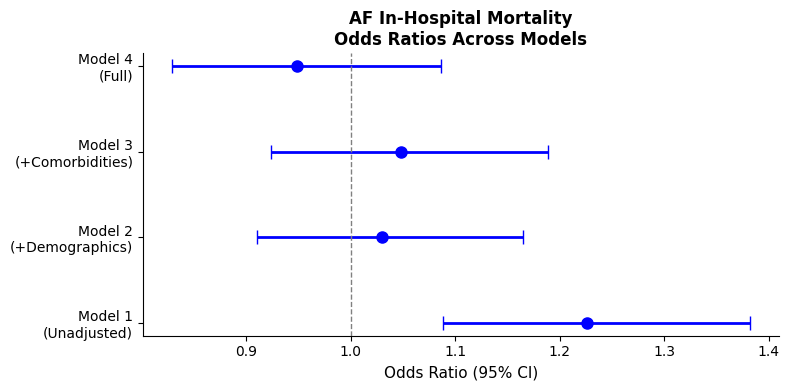

In [5]:
models_list = [
    ('Model 1\n(Unadjusted)', r1),
    ('Model 2\n(+Demographics)', r2),
    ('Model 3\n(+Comorbidities)', r3),
    ('Model 4\n(Full)', r4)
]

ors  = [r.loc['has_af_index','OR']    for _, r in models_list]
los  = [r.loc['has_af_index','CI_lo'] for _, r in models_list]
his  = [r.loc['has_af_index','CI_hi'] for _, r in models_list]
lbls = [l for l, _ in models_list]

fig, ax = plt.subplots(figsize=(8, 4))
y = range(len(ors))
ax.errorbar(ors, y,
            xerr=[np.array(ors)-np.array(los), np.array(his)-np.array(ors)],
            fmt='o', color = 'blue', ecolor = 'blue',
            markersize=8, capsize=5, linewidth=2)
ax.axvline(x=1, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(list(y))
ax.set_yticklabels(lbls, fontsize=10)
ax.set_xlabel('Odds Ratio (95% CI)', fontsize=11)
ax.set_title('AF In-Hospital Mortality\nOdds Ratios Across Models', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('forest_plot.png', dpi=100, bbox_inches='tight')
plt.show()

## 2.4 Subgroup Analysis: HFrEF vs HFpEF

In [6]:
subgroup_formula = (
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + '
    'creatinine_max + bun_max + sodium_min + hemoglobin_min + '
    'heart_rate_max + sbp_min + spo2_min'
)

print('Subgroup analysis: HFrEF')
hfref_df = df[df['is_hfref'] == 1]
print(f'N={len(hfref_df)}, Deaths={hfref_df.hospital_expire_flag.sum()}')
m_hfref = smf.logit(subgroup_formula, data=hfref_df).fit(disp=0)
or_hfref = np.exp(m_hfref.params['has_af_index'])
ci_hfref = np.exp(m_hfref.conf_int().loc['has_af_index'])
p_hfref  = m_hfref.pvalues['has_af_index']
print(f'AF OR: {or_hfref:.2f} ({ci_hfref[0]:.2f}–{ci_hfref[1]:.2f}), p={p_hfref:.3f}')

print('\nSubgroup analysis: HFpEF')
hfpef_df = df[df['is_hfpef'] == 1]
print(f'N={len(hfpef_df)}, Deaths={hfpef_df.hospital_expire_flag.sum()}')
m_hfpef = smf.logit(subgroup_formula, data=hfpef_df).fit(disp=0)
or_hfpef = np.exp(m_hfpef.params['has_af_index'])
ci_hfpef = np.exp(m_hfpef.conf_int().loc['has_af_index'])
p_hfpef  = m_hfpef.pvalues['has_af_index']
print(f'AF OR: {or_hfpef:.2f} ({ci_hfpef[0]:.2f}–{ci_hfpef[1]:.2f}), p={p_hfpef:.3f}')

print('\nInteration test (AF and HF subtype)')
df_sub = df[df['is_hfref']+df['is_hfpef'] > 0].copy()
df_sub['interaction'] = df_sub['has_af_index'] * df_sub['is_hfref']
int_formula = (
    'hospital_expire_flag ~ has_af_index + is_hfref + interaction + '
    'age_at_admit + female + has_htn + has_dm + has_ckd + has_cad + '
    'creatinine_max + bun_max + sodium_min + heart_rate_max + sbp_min + spo2_min'
)
m_int = smf.logit(int_formula, data=df_sub).fit(disp=0)
p_int = m_int.pvalues['interaction']

print(f'Interaction p-value: {p_int:.3f}')
if p_int < 0.05:
    print('There is significant interaction: AF effect differs between HFrEF and HFpEF')
else:
    print('There is no significant interaction: AF effect is similar in HFrEF and HFpEF')

Subgroup analysis: HFrEF
N=4577, Deaths=629


AF OR: 0.97 (0.80–1.16), p=0.715

Subgroup analysis: HFpEF
N=4245, Deaths=530
AF OR: 0.90 (0.74–1.11), p=0.331

Interation test (AF and HF subtype)
Interaction p-value: 0.952
There is no significant interaction: AF effect is similar in HFrEF and HFpEF


## 2.5 Sensitivity Analysis: Alternate AF Definition

In [7]:
print('Sensitivity analysis note:')
print('Primary cohort AF prevalence:', df['has_af_index'].mean().round(3))
print('Primary Model 4 OR for AF:', r4.loc['has_af_index','OR (95% CI)'])
print()

print('To run sensitivity analysis:')
print('1. In R, re-run cohort.Rmd with AF restricted to seq_num <= 3')
print('2. Export as analytic_dataset_sensitivity.csv')
print('3. Re-run Model 4 on that dataset and compare OR')

Sensitivity analysis note:
Primary cohort AF prevalence: 0.399
Primary Model 4 OR for AF: 0.95 (0.83–1.09)

To run sensitivity analysis:
1. In R, re-run cohort.Rmd with AF restricted to seq_num <= 3
2. Export as analytic_dataset_sensitivity.csv
3. Re-run Model 4 on that dataset and compare OR


## 2.6 Model Diagnostics

In [8]:
vif_cols = [
    'has_af_index','age_at_admit','female',
    'has_htn','has_dm','has_ckd','has_cad','has_copd','has_cardiomyopathy',
    'icu_cardiac','icu_medical',
    'creatinine_max','bun_max','sodium_min','potassium_max',
    'hemoglobin_min','wbc_max','anion_gap_max',
    'heart_rate_max','sbp_min','spo2_min'
]
vif_data = df[vif_cols].dropna()
X_vif = sm.add_constant(vif_data)

vif_results = pd.DataFrame({
    'Variable': vif_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i+1)
            for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print('VIF Results')
print(vif_results.round(2).to_string(index=False))

high_vif = vif_results[vif_results['VIF'] > 5]
if len(high_vif):
    print(f'\nHigh VIF (>5): {list(high_vif.Variable)}')
else:
    print('\nNo multicollinearity issues since all VIF <5')

VIF Results
          Variable   VIF
       icu_cardiac 2.380
       icu_medical 2.290
    creatinine_max 2.110
           bun_max 1.980
     anion_gap_max 1.500
           has_ckd 1.480
      age_at_admit 1.310
     potassium_max 1.190
           has_cad 1.160
    hemoglobin_min 1.150
    heart_rate_max 1.150
           has_htn 1.140
            has_dm 1.130
           sbp_min 1.130
            female 1.110
      has_af_index 1.080
           wbc_max 1.080
has_cardiomyopathy 1.080
        sodium_min 1.070
          spo2_min 1.040
          has_copd 1.040

No multicollinearity issues since all VIF <5


## 2.7 Sensitivity: Race recoded to 3 levels (White / Black / Other)

Refit Models 2–4 with race collapsed into **White** (reference) / **Black** / **Other** (Hispanic + Asian + Other/Unknown). Compare AF OR against original 5-level coding to check robustness.

In [9]:
# Sensitivity: race recoded to 3 levels (White / Black / Other), White as reference

def recode_race_3(r):
    if pd.isna(r): return 'Other'
    r = str(r).upper()
    if 'WHITE' in r: return 'White'
    if 'BLACK' in r: return 'Black'
    return 'Other'

df['race_group3'] = df['race'].apply(recode_race_3)

print('Race distribution (3-level):')
print(df['race_group3'].value_counts())
print(f'Total: {len(df)}')
print()

# Re-run Models 2, 3, 4 with 3-level race (White = reference)
m2_s, r2_s = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'C(race_group3, Treatment(reference="White")) + '
    'C(insurance_group, Treatment(reference="Medicare"))',
    df, 'Model 2 (sensitivity, race 3-level)')

m3_s, r3_s = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'C(race_group3, Treatment(reference="White")) + '
    'C(insurance_group, Treatment(reference="Medicare")) + '
    'is_hfref + is_hfpef + is_hfmixed + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_valvular + '
    'has_pad + has_stroke_hx + has_pulm_htn + has_cardiomyopathy',
    df, 'Model 3 (sensitivity, race 3-level)')

m4_s, r4_s = fit_logistic(
    'hospital_expire_flag ~ has_af_index + age_at_admit + female + '
    'C(race_group3, Treatment(reference="White")) + '
    'has_htn + has_dm + has_ckd + has_cad + has_copd + has_cardiomyopathy + '
    'icu_cardiac + icu_medical + '
    'creatinine_max + bun_max + sodium_min + potassium_max + '
    'hemoglobin_min + wbc_max + anion_gap_max + '
    'heart_rate_max + sbp_min + spo2_min',
    df, 'Model 4 (sensitivity, race 3-level)')

# Compare AF OR across original (5-level) vs sensitivity (3-level)
sens_summary = pd.DataFrame({
    'Model': ['Model 2', 'Model 3', 'Model 4'],
    'Original (5-level race) AF OR': [
        r2.loc['has_af_index','OR (95% CI)'],
        r3.loc['has_af_index','OR (95% CI)'],
        r4.loc['has_af_index','OR (95% CI)']
    ],
    'Sensitivity (3-level race) AF OR': [
        r2_s.loc['has_af_index','OR (95% CI)'],
        r3_s.loc['has_af_index','OR (95% CI)'],
        r4_s.loc['has_af_index','OR (95% CI)']
    ]
})
print('\nAF OR comparison: original (5-level race) vs sensitivity (3-level race, White ref)')
print(sens_summary.to_string(index=False))

Race distribution (3-level):
race_group3
White    6197
Other    2265
Black    1001
Name: count, dtype: int64
Total: 9463




Model 2 (sensitivity, race 3-level) N=9,463 AUC=0.623


,OR (95% CI),p-value
Intercept,0.02 (0.01–0.03),<0.001
Race: Black,1.02 (0.81–1.27),0.881
Race: Other,1.67 (1.45–1.91),<0.001
Insurance: Medicaid,0.70 (0.54–0.90),0.005
Insurance: Missing/Unknown,1.01 (0.49–2.07),0.973
Insurance: Other,0.38 (0.18–0.83),0.014
Insurance: Private,0.89 (0.73–1.09),0.258
Atrial fibrillation,1.04 (0.92–1.17),0.571
Age (per year),1.03 (1.02–1.03),<0.001
Female sex,0.94 (0.83–1.06),0.338



Model 3 (sensitivity, race 3-level) N=9,463 AUC=0.654

,OR (95% CI),p-value
Intercept,0.01 (0.00–0.02),<0.001
Race: Black,0.95 (0.76–1.20),0.695
Race: Other,1.64 (1.43–1.88),<0.001
Insurance: Medicaid,0.69 (0.54–0.90),0.005
Insurance: Missing/Unknown,1.04 (0.51–2.14),0.910
Insurance: Other,0.39 (0.18–0.84),0.016
Insurance: Private,0.92 (0.75–1.13),0.415
Atrial fibrillation,1.05 (0.93–1.20),0.403
Age (per year),1.03 (1.02–1.04),<0.001
Female sex,0.98 (0.87–1.12),0.812



Model 4 (sensitivity, race 3-level) N=9,248 AUC=0.760


,OR (95% CI),p-value
Intercept,0.61 (0.08–4.68),0.638
Race: Black,1.07 (0.84–1.36),0.586
Race: Other,1.71 (1.47–1.97),<0.001
Atrial fibrillation,0.96 (0.84–1.10),0.528
Age (per year),1.03 (1.02–1.04),<0.001
Female sex,0.90 (0.79–1.03),0.143
Hypertension,0.84 (0.71–1.01),0.059
Diabetes mellitus,0.91 (0.79–1.04),0.162
Chronic kidney disease,1.09 (0.94–1.27),0.260
Coronary artery disease,1.02 (0.88–1.18),0.787



AF OR comparison: original (5-level race) vs sensitivity (3-level race, White ref)
  Model Original (5-level race) AF OR Sensitivity (3-level race) AF OR
Model 2              1.03 (0.91–1.17)                 1.04 (0.92–1.17)
Model 3              1.05 (0.92–1.19)                 1.05 (0.93–1.20)
Model 4              0.95 (0.83–1.09)                 0.96 (0.84–1.10)


## 2.8 NOAF vs No AF, 3 horizons × 3 model specs

Table 3 layout:
- **Outcomes**: 3-month / 6-month / 1-year all-cause mortality (Cox PH)
- **Model specs (nested)**:
  - **Unadjusted model**: `has_af_index` only
  - **Basic model**: + age, sex, race, insurance
  - **Multivariate model**: + HF subtype + 10 comorbidities
- **Reference**: No AF (`has_af_index = 0`)
- 9 hazard-ratio cells total


Mortality counts by horizon:
  3-month (90-day): 2,149 (22.7%)
  6-month (180-day): 2,558 (27.0%)
  1-year (365-day): 3,150 (33.3%)

Group sizes:  No AF = 5,687, NOAF (has_af_index=1) = 3,776



=== NOAF vs No AF — Zhang-style nested Cox table ===

          Section                Model         No AF     NOAF HR (95% CI) p-value
3-month mortality                                                                
                      Unadjusted model 1 (Reference) 1.160 (1.065, 1.263)  <0.001
                           Basic model 1 (Reference) 0.970 (0.889, 1.059)   0.495
                    Multivariate model 1 (Reference) 0.984 (0.901, 1.074)   0.716
6-month mortality                                                                
                      Unadjusted model 1 (Reference) 1.172 (1.084, 1.267)  <0.001
                           Basic model 1 (Reference) 0.991 (0.915, 1.074)   0.828
                    Multivariate model 1 (Reference) 1.008 (0.930, 1.093)   0.842
 1-year mortality                                                                
                      Unadjusted model 1 (Reference) 1.131 (1.054, 1.214)  <0.001
                           Basic model 1 (R

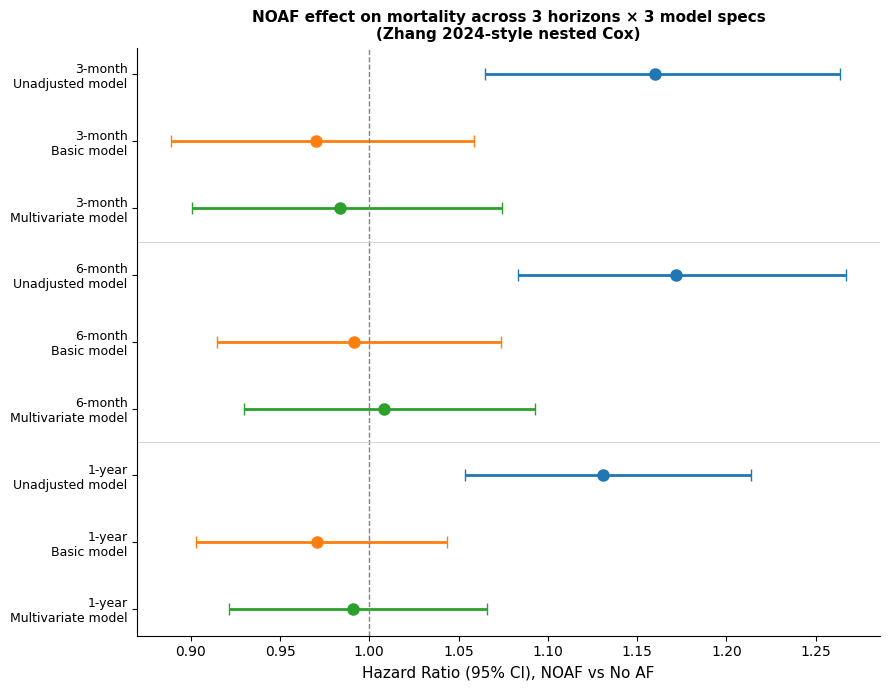

In [10]:

from statsmodels.duration.hazard_regression import PHReg

# Compute time-to-event and event indicators at 3-month, 6-month, 1-year
df['admittime_dt']  = pd.to_datetime(df['admittime'], format='mixed', errors='coerce')
df['dod_dt']        = pd.to_datetime(df['dod'],       errors='coerce')
df['days_to_death'] = (df['dod_dt'] - df['admittime_dt']).dt.total_seconds() / 86400

HORIZONS = [(90, '3-month'), (180, '6-month'), (365, '1-year')]

for h, _ in HORIZONS:
    df[f'death_{h}d'] = ((df['days_to_death'].notna()) &
                         (df['days_to_death'] <= h) &
                         (df['days_to_death'] >= 0)).astype(int)
    t = df['days_to_death'].fillna(h + 1).clip(lower=0.5, upper=h)
    df[f'time_to_event_{h}d'] = t

print('Mortality counts by horizon:')
for h, lbl in HORIZONS:
    n = df[f'death_{h}d'].sum()
    print(f'  {lbl} ({h}-day): {n:,} ({100*n/len(df):.1f}%)')
print()
print(f"Group sizes:  No AF = {(df['has_af_index']==0).sum():,}, "
      f"NOAF (has_af_index=1) = {(df['has_af_index']==1).sum():,}")

# Three nested model specifications
MODELS = [
    ('Unadjusted model', ''),
    ('Basic model',
     'age_at_admit + female + '
     'C(race_group, Treatment(reference="White")) + '
     'C(insurance_group, Treatment(reference="Medicare"))'),
    ('Multivariate model',
     'age_at_admit + female + '
     'C(race_group, Treatment(reference="White")) + '
     'C(insurance_group, Treatment(reference="Medicare")) + '
     'is_hfref + is_hfpef + is_hfmixed + '
     'has_htn + has_dm + has_ckd + has_cad + has_copd + has_valvular + '
     'has_pad + has_stroke_hx + has_pulm_htn + has_cardiomyopathy')
]

def fit_cox_simple(time_col, event_col, exposure, covariates, data):
    df_use = data.dropna(subset=[time_col, event_col, exposure]).copy()
    formula = f'{time_col} ~ {exposure}'
    if covariates.strip():
        formula += f' + {covariates}'
    mod = PHReg.from_formula(formula, data=df_use,
                             status=df_use[event_col].values)
    res = mod.fit(disp=0)
    idx = res.model.exog_names.index(exposure)
    coef = float(res.params[idx])
    se   = float(res.bse[idx])
    pval = float(res.pvalues[idx])
    hr    = float(np.exp(coef))
    ci_lo = float(np.exp(coef - 1.96 * se))
    ci_hi = float(np.exp(coef + 1.96 * se))
    return hr, ci_lo, ci_hi, pval


rows = []
plot_data = []  # for forest plot: (label, hr, lo, hi)

for h, h_label in HORIZONS:
    rows.append({
        'Section':           f'{h_label} mortality',
        'Model':             '',
        'No AF':             '',
        'NOAF HR (95% CI)':  '',
        'p-value':           ''
    })
    for m_label, m_cov in MODELS:
        hr, lo, hi, p = fit_cox_simple(
            f'time_to_event_{h}d', f'death_{h}d',
            'has_af_index', m_cov, df)
        rows.append({
            'Section':          '',
            'Model':            f'  {m_label}',
            'No AF':            '1 (Reference)',
            'NOAF HR (95% CI)': f'{hr:.3f} ({lo:.3f}, {hi:.3f})',
            'p-value':          '<0.001' if p < 0.001 else f'{p:.3f}'
        })
        plot_data.append((f'{h_label}\n{m_label}', hr, lo, hi))

zhang_table = pd.DataFrame(rows)
print('\n=== NOAF vs No AF — Zhang-style nested Cox table ===\n')
print(zhang_table.to_string(index=False))
zhang_table.to_csv('zhang_style_cox_table.csv', index=False)

# Forest plot: 9 HRs in 3 outcome × 3 model grid
fig, ax = plt.subplots(figsize=(9, 7))
labels = [d[0] for d in plot_data]
hrs    = np.array([d[1] for d in plot_data])
los    = np.array([d[2] for d in plot_data])
his    = np.array([d[3] for d in plot_data])
y      = np.arange(len(plot_data))

# color by model spec (3 colors recycling)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] * len(HORIZONS)

for i in range(len(plot_data)):
    ax.errorbar(hrs[i], y[i],
                xerr=[[hrs[i]-los[i]], [his[i]-hrs[i]]],
                fmt='o', color=colors[i], ecolor=colors[i],
                markersize=8, capsize=4, linewidth=2)

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1)
# horizontal separators between outcomes
for sep in [2.5, 5.5]:
    ax.axhline(y=sep, color='lightgray', linewidth=0.7)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Hazard Ratio (95% CI), NOAF vs No AF', fontsize=11)
ax.set_title('NOAF effect on mortality across 3 horizons × 3 model specs\n'
             '(Zhang 2024-style nested Cox)',
             fontsize=11, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('zhang_style_cox_forest.png', dpi=100, bbox_inches='tight')
plt.show()